## LAB 11: Preprocesamiento de Datos para machine learning

**Objetivo** : Aplicar las principales técnicas de preprocesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML.

**Problema** : Se desea construir un modelo capaz de predecir si un pasajero sobrevivio o no al hundimiento del titanic

In [35]:
#Importamos las librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
!pip install -U kagglehub

In [4]:
import kagglehub

In [15]:
import kagglehub

print(kagglehub.dataset_download)

path = kagglehub.dataset_download("yasserh/titanic-dataset")

print(path)

<function dataset_download at 0x00000226026C9DA0>
C:\Users\jerry\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [17]:
print ("Ruta del dataset:", path)

Ruta del dataset: C:\Users\jerry\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [19]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [21]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Parte 1. Comprension del problema
Determinar si sobreviven al hundimiento del titanic, con base en la informacion obtenida

suvervid:


0: no sobrevivio

1: si sobrevio

In [31]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

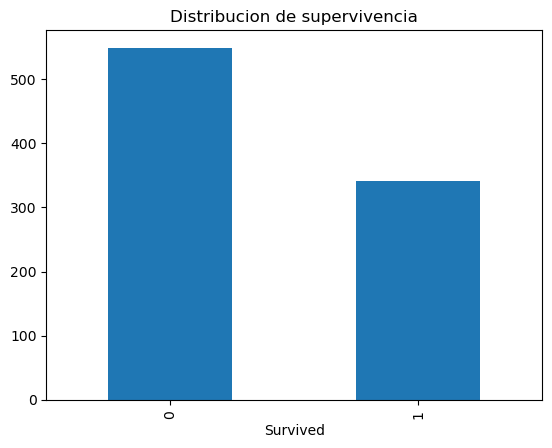

In [39]:
#Graficamos
dfTitanic["Survived"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de supervivencia")
plt.show()

## Parte 2.Exploracion inicial 

In [41]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [43]:
#Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [45]:
#Hipotesis inicial
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [47]:
#Hipotesis inicial
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis

Creamos una matriz de correlacion para identificar la relacion lineal entre las variables. NO identica la importancia de variables en el modelo

In [55]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [57]:
corr = dfTitanic[variables_numericas].corr()

In [59]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


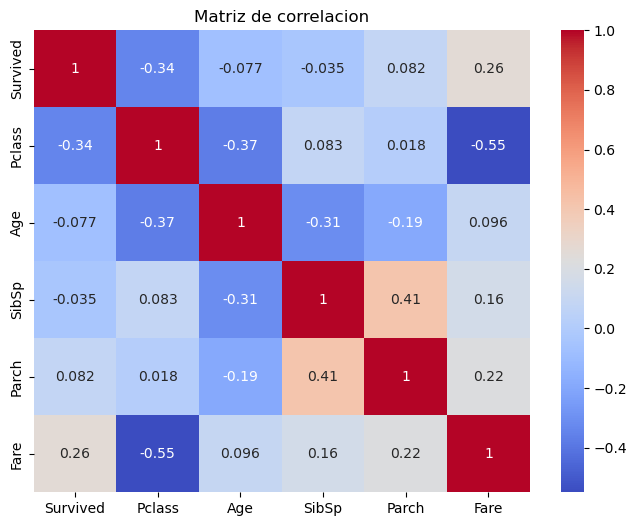

In [61]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

# Parte 4. Seleccion de variables predictorias y variabe objetivo

X - Variables que utilizara el modelo

Y - Variable que queremos predecir

In [64]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [68]:
#Definimos x y
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [72]:
print(x.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [74]:
print(y.name)

Survived


## Parte 5. Tratamiento de los valores

Para simplificar el proceso, realizaremos la imputacion de los datos antes de la separacion TRAIN/TEST

In [80]:
#Revisamos .as variables predictoras
x.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [90]:
x["Age"] = x["Age"].fillna(
    x["Age"].median()
)

C:\Users\jerry\AppData\Local\Temp\ipykernel_21396\1295983609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Age"] = x["Age"].fillna(


In [94]:
x["Embarked"] = x["Embarked"].fillna(
    x["Embarked"].mode()[0]
)

C:\Users\jerry\AppData\Local\Temp\ipykernel_21396\1058067266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Embarked"] = x["Embarked"].fillna(


In [96]:
x.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [98]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Parte 6. Escalado de datos

Los algoritmos no entienden texto. Se deben convertir las variables categoricas en variables numericas

In [101]:
x = pd.get_dummies(
    x,
    columns = ["Sex", "Embarked"],
    drop_first = True
)

In [103]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Parte 7. Particionamos los datos

No debemos entrenar y evaluar utilizando los mismo datos.

La recomendación es:

Entrenamiento: 80%
Pruebas: 20%

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42
)

In [109]:
print ("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [111]:
print ("¨Prueba: ", y_test.shape)

¨Prueba:  (179,)


## Parte 8. Escalado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine mas que otra

In [116]:
columnas_numericas =[
    "Age",
    "Fare",
    "SibSp",
    "Parch",
]

In [118]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [120]:
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)
X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [122]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17,1.746418e-17,2.245395e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01,-4.707224e-01,-4.793416e-01
25%,-5.542135e-01,-4.748670e-01,-4.707224e-01,-4.793416e-01
50%,-9.263364e-02,-3.491435e-01,-4.707224e-01,-4.793416e-01
75%,4.458762e-01,-4.017244e-02,3.799232e-01,-4.793416e-01
max,3.907725e+00,9.237724e+00,6.334442e+00,7.104908e+00


## Parte 9. Entrenamiento delos datos

Usaremos un arbol de decision para clasificar registros

In [127]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state = 42
)

In [147]:
modelo.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

## Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo

In [133]:
predicciones = modelo.predict(
    X_test
)

In [139]:
pd.DataFrame({
   "Real": y_test,
    "Prediccion": predicciones
}).head(15)

,Real,Prediccion
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Parte 11. Evaluacion del modelo

El accuracy determinar el porcentaje de predicciones correctas realizadas por el modelo

In [152]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [154]:
print (f"Accuracy : {accuracy: .4f}")

Accuracy :  0.7989


|Accuracy | Interpretacion |
|---------|----------------|
| 50% | Adivina |
| 60-70% | Aceptable  / Basico |
| 70-80% | Bueno |
| 80-90% | Muy bueno |
| >90% | Excelente (posible sobreajuste) |

## Parte 12. Importancia de las variables

Analizar las variables mas relevantes para el algoritmo, al realizar las predicciones

In [162]:
importancias = pd.DataFrame({
    "Variable" : X_train.columns,
    "Importancia" : modelo.feature_importances_ #que variable es importante para el modelo
})

In [164]:
importancias.sort_values(
    by = "Importancia",
    ascending = False
)

,Variable,Importancia
5,Sex_male,0.579608
0,Pclass,0.200498
4,Fare,0.081064
1,Age,0.078872
2,SibSp,0.046059
7,Embarked_S,0.013900
3,Parch,0.000000
6,Embarked_Q,0.000000
